# Previsão da Área de Atuação Profissional em Medicina Veterinária

## Aplicação interativa para a Feira de Ciências da Escola de Veterinária da UFMG

Este notebook documenta o desenvolvimento de uma aplicação recreativa de visão computacional.

O sistema:

- captura imagens ao vivo de uma câmera;
- detecta e rastreia várias pessoas simultaneamente;
- atribui uma área profissional por sorteio a cada pessoa rastreada;
- mantém o resultado enquanto o mesmo ID permanecer ativo;
- destaca as pessoas que entram em uma região central ampla;
- apresenta o resultado em uma TV conectada como segundo monitor;
- não reconhece identidades;
- não armazena imagens ou vídeos.

> **Transparência:** a inteligência artificial é utilizada para detectar e rastrear pessoas. A área profissional é escolhida por sorteio e não é inferida a partir da aparência.

## 1. Arquitetura do sistema

O programa executará continuamente as seguintes operações:

1. captura um quadro da câmera;
2. espelha horizontalmente a imagem;
3. detecta pessoas com um modelo YOLO pré-treinado;
4. usa o ByteTrack para manter IDs temporários;
5. sorteia uma área para cada novo ID;
6. mantém a mesma área enquanto o ID estiver ativo;
7. desenha caixas e resultados;
8. destaca quem estiver dentro da região central;
9. apresenta a composição em tela cheia na TV;
10. remove da memória os IDs que desapareceram.

Não será necessário treinar um modelo ou criar um banco de imagens.

## 2. Criação do ambiente

### Onde executar

Os comandos abaixo devem ser executados no **Anaconda Prompt**, uma linha por vez.

Não execute esses comandos como uma célula Python.

```text
conda create -n feira_vet python=3.11 -y
conda activate feira_vet

python -m pip install --upgrade pip
python -m pip install ultralytics opencv-python pillow screeninfo matplotlib jupyterlab

python -m ipykernel install --user --name feira_vet --display-name "Python (feira_vet)"

jupyter lab

## 3. Conferência do ambiente

### Onde executar

Execute a próxima célula no **JupyterLab**.

Ela verifica se as bibliotecas foram instaladas e mostra as versões utilizadas.

In [2]:
# EXECUTAR NO JUPYTERLAB

import sys
import cv2
import PIL
import ultralytics
import screeninfo

print("Python:", sys.version)
print("OpenCV:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("Ultralytics:", ultralytics.__version__)
print("\nAmbiente carregado com sucesso.")

Python: 3.11.16 | packaged by conda-forge | (main, Sep  2 2026, 23:31:17) [MSC v.1944 64 bit (AMD64)]
OpenCV: 4.10.0
Pillow: 12.3.0
Ultralytics: 8.4.152

Ambiente carregado com sucesso.


## 4. Identificação dos monitores

A TV deve ser conectada ao notebook por HDMI. No Windows, deve-se selecionar:

**Configurações de exibição → Vários monitores → Estender estes vídeos**

O monitor do notebook geralmente aparece com índice 0 e a TV com índice 1. Essa ordem deve ser conferida porque pode variar entre computadores.

### Onde executar

Execute a próxima célula no **JupyterLab**, depois de conectar a TV.

In [3]:
# EXECUTAR NO JUPYTERLAB

from screeninfo import get_monitors

monitores = get_monitors()

for indice, monitor in enumerate(monitores):
    print(
        f"[{indice}] "
        f"resolução={monitor.width}x{monitor.height} | "
        f"posição=({monitor.x}, {monitor.y}) | "
        f"principal={getattr(monitor, 'is_primary', False)}"
    )

[0] resolução=1920x1080 | posição=(0, 0) | principal=True
[1] resolução=1920x1080 | posição=(1920, -69) | principal=False


## 5. Teste da câmera

A câmera integrada normalmente possui índice 0. Uma webcam USB pode receber índice 1 ou 2.

A próxima célula captura apenas uma imagem, libera imediatamente a câmera e mostra o resultado dentro do notebook.

### Onde executar

Execute a próxima célula no **JupyterLab**.

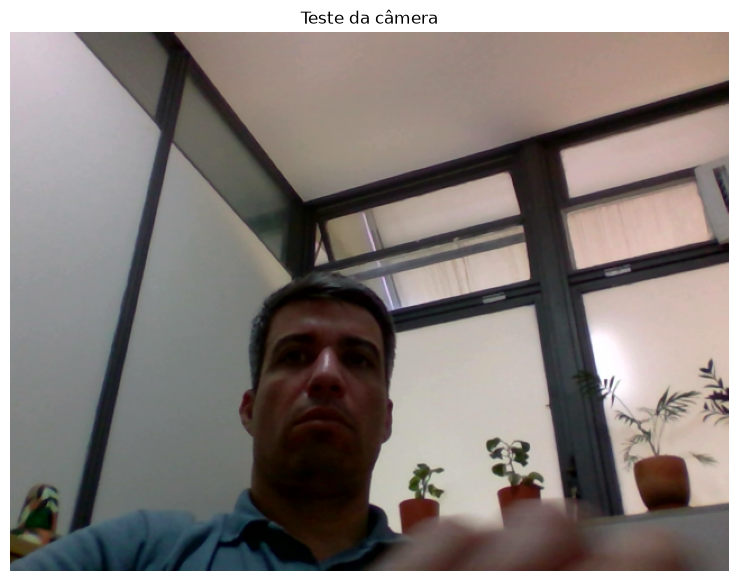

In [4]:
# EXECUTAR NO JUPYTERLAB

import cv2
import matplotlib.pyplot as plt

INDICE_CAMERA = 0

cap = cv2.VideoCapture(INDICE_CAMERA, cv2.CAP_DSHOW)
sucesso, frame = cap.read()
cap.release()

if not sucesso:
    raise RuntimeError(
        "Não foi possível capturar a imagem. "
        "Feche outros programas que possam estar usando a câmera."
    )

# Espelha a imagem como em um espelho
frame = cv2.flip(frame, 1)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Teste da câmera")
plt.show()

## 6. Carregamento do modelo YOLO

Será utilizado um modelo YOLO pequeno e pré-treinado. O modelo já reconhece a classe “pessoa”, portanto não será necessário realizar treinamento.

O arquivo do modelo será baixado automaticamente na primeira execução.

### Onde executar

Execute a próxima célula no **JupyterLab**.

In [5]:
# EXECUTAR NO JUPYTERLAB

from ultralytics import YOLO

modelo = YOLO("yolo11n.pt")

print("Modelo carregado com sucesso.")

Modelo carregado com sucesso.


## 7. Teste da detecção de pessoas

A classe 0 do conjunto utilizado pelo YOLO corresponde a “pessoa”.

O parâmetro `conf=0.35` determina a confiança mínima aceita. Valores menores podem detectar pessoas mais distantes, mas também aumentam a possibilidade de falsas detecções.

### Onde executar

Execute a próxima célula no **JupyterLab**.

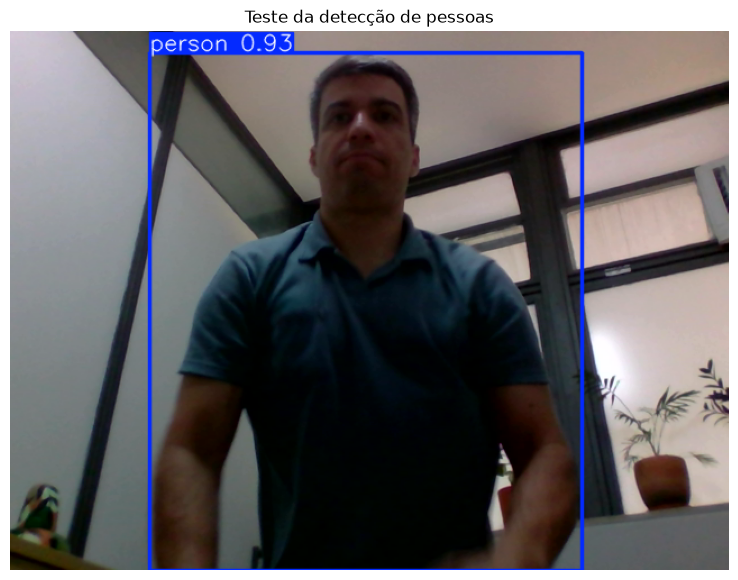

In [7]:
# EXECUTAR NO JUPYTERLAB

import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(INDICE_CAMERA, cv2.CAP_DSHOW)
sucesso, frame = cap.read()
cap.release()

if not sucesso:
    raise RuntimeError("Não foi possível capturar uma imagem.")

frame = cv2.flip(frame, 1)

resultado = modelo.predict(
    frame,
    classes=[0],       # somente pessoas
    conf=0.35,
    imgsz=640,
    verbose=False
)[0]

imagem_anotada = resultado.plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(imagem_anotada, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Teste da detecção de pessoas")
plt.show()

## 8. Áreas profissionais e pesos

As áreas são sorteadas com a função `random.choices`.

Inicialmente, todas possuem o mesmo peso. Os números podem ser modificados, e sua soma não precisa ser igual a 100. Somente a proporção entre os valores é utilizada.

Pesos personalizados não devem ser apresentados como representação do mercado de trabalho sem uma fonte confiável.

In [8]:
# EXECUTAR NO JUPYTERLAB

import random

AREAS_E_PESOS = {
    "Clínica e cirurgia de pequenos animais": 1.0,
    "Clínica e cirurgia de grandes animais": 1.0,
    "Clínica de animais selvagens": 1.0,
    "Tecnologia e inspeção de produtos de origem animal": 1.0,
    "Produção de grandes animais": 1.0,
    "Produção de pequenos animais": 1.0,
    "Nutrição animal": 1.0,
    "Genética e melhoramento animal": 1.0,
    "Medicina veterinária preventiva": 1.0
}

area_sorteada = random.choices(
    list(AREAS_E_PESOS.keys()),
    weights=list(AREAS_E_PESOS.values()),
    k=1
)[0]

print("Exemplo de resultado:", area_sorteada)

Exemplo de resultado: Clínica e cirurgia de pequenos animais


## 9. Rastreamento e estabilidade do resultado

A detecção encontra pessoas em cada quadro, mas não informa se uma caixa corresponde à mesma pessoa encontrada no quadro anterior.

O ByteTrack acrescenta um ID temporário para cada pessoa. O programa associa a área sorteada a esse ID.

Para reduzir resultados instáveis:

- a pessoa precisa aparecer durante pelo menos três quadros;
- o sorteio é realizado somente uma vez por ID;
- o resultado é mantido durante ocultações breves;
- IDs ausentes por mais de dez segundos são removidos;
- o programa não mantém um histórico permanente.

O ID não corresponde à identidade real. Caso duas pessoas se cruzem ou uma pessoa saia e retorne, um novo ID poderá ser criado.

## 10. Geração do programa final

A próxima célula cria automaticamente o arquivo `feira_vet_app.py` na mesma pasta do notebook.

O arquivo poderá ser executado independentemente pelo Anaconda Prompt, o que tende a ser mais estável para a feira.

### Onde executar

Execute a próxima célula uma única vez no **JupyterLab**.

A primeira linha `%%writefile` é um comando próprio do JupyterLab.

In [20]:
%%writefile feira_vet_app.py
"""
Feira de Ciências da Escola de Veterinária da UFMG

Aplicação recreativa para:

- detectar e rastrear várias pessoas;
- sortear uma área de atuação profissional;
- manter o resultado enquanto o ID permanecer ativo;
- destacar pessoas dentro de uma região central;
- exibir a imagem em uma TV;
- não armazenar imagens ou vídeos.

Para encerrar, pressione Q ou ESC na janela da aplicação.
"""

from __future__ import annotations

import argparse
import random
import sys
import time
import traceback
from functools import lru_cache
from pathlib import Path

import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from screeninfo import get_monitors
from ultralytics import YOLO


# ============================================================
# 1. CONFIGURAÇÕES PRINCIPAIS
# ============================================================

TITULO = (
    "Preveja a sua Área de Atuação Profissional\n"
    "em Medicina Veterinária"
)

RODAPE = (
    "Resultado recreativo gerado por sorteio — "
    "não constitui orientação profissional"
)

MENSAGEM_AREA = (
    "Entre nesta área e descubra seu futuro!"
)

# Modelo pequeno e apropriado para execução em tempo real
MODELO_YOLO = "yolo11n.pt"

# Rastreador adequado para câmera fixa
TRACKER = "bytetrack.yaml"

# Índices padrão
CAMERA_PADRAO = 0
MONITOR_TV_PADRAO = 1

# Configurações da câmera
LARGURA_CAMERA = 1280
ALTURA_CAMERA = 720
FPS_CAMERA = 30

# Configurações da detecção
CONFIANCA_MINIMA = 0.35
IOU_MINIMO = 0.50
TAMANHO_INFERENCIA = 640
MAXIMO_PESSOAS = 20

# Número mínimo de quadros antes de realizar o sorteio
QUADROS_PARA_SORTEIO = 3

# Tempo, em segundos, para remover um ID ausente
TEMPO_PARA_REMOVER_ID = 10.0

# Região central expressa como proporção da imagem
ROI_X1 = 0.15
ROI_Y1 = 0.20
ROI_X2 = 0.85
ROI_Y2 = 0.92

# Mostra o número de pessoas detectadas e o FPS
MOSTRAR_STATUS = True


# ============================================================
# 2. ÁREAS PROFISSIONAIS E PESOS
# ============================================================

# Os pesos estão iguais por padrão.
#
# Os valores podem ser alterados sem que a soma seja igual a 100.
# Apenas a proporção entre os números é considerada.
#
# Não apresente pesos personalizados como proporções reais do
# mercado de trabalho sem uma fonte confiável.

AREAS_E_PESOS = {
    "Clínica e cirurgia\nde pequenos animais": 1.0,

    "Clínica e cirurgia\nde grandes animais": 1.0,

    "Clínica de\nanimais selvagens": 1.0,

    "Tecnologia e inspeção de\nprodutos de origem animal": 1.0,

    "Produção de\ngrandes animais": 1.0,

    "Reprodução": 1.0,

    "Diagnóstico por imagem": 1.0,

    "Patologia Veterinária": 1.0,

    "Nutrição animal": 1.0,

    "Genética e melhoramento\nanimal": 1.0,

    "Medicina veterinária\npreventiva": 1.0,

    "Pesquisa veterinária\nprofessor": 1.0
}


# ============================================================
# 3. FUNÇÕES AUXILIARES
# ============================================================

def sortear_area():
    """
    Sorteia uma área profissional de acordo com os pesos.
    """

    areas = list(AREAS_E_PESOS.keys())
    pesos = list(AREAS_E_PESOS.values())

    area = random.choices(
        areas,
        weights=pesos,
        k=1
    )[0]

    return area


@lru_cache(maxsize=20)
def carregar_fonte(
    tamanho,
    negrito=False
):
    """
    Carrega uma fonte do Windows.

    O uso de Pillow permite mostrar corretamente
    caracteres acentuados.
    """

    pasta_fontes = Path(
        "C:/Windows/Fonts"
    )

    if negrito:
        nomes_fontes = [
            "arialbd.ttf",
            "segoeuib.ttf"
        ]

    else:
        nomes_fontes = [
            "arial.ttf",
            "segoeui.ttf"
        ]

    for nome_fonte in nomes_fontes:
        caminho_fonte = (
            pasta_fontes /
            nome_fonte
        )

        if caminho_fonte.exists():
            return ImageFont.truetype(
                str(caminho_fonte),
                tamanho
            )

    # Fonte de reserva
    return ImageFont.load_default()


def texto_centralizado(
    draw,
    texto,
    centro_x,
    topo_y,
    fonte,
    cor=(255, 255, 255),
    espacamento=4,
    contorno=0,
    cor_contorno=(0, 0, 0)
):
    """
    Desenha texto multilinha centralizado.
    """

    bbox = draw.multiline_textbbox(
        (0, 0),
        texto,
        font=fonte,
        spacing=espacamento,
        align="center",
        stroke_width=contorno
    )

    largura_texto = (
        bbox[2] -
        bbox[0]
    )

    posicao_x = (
        centro_x -
        largura_texto / 2
    )

    draw.multiline_text(
        (
            posicao_x,
            topo_y
        ),
        texto,
        font=fonte,
        fill=cor,
        spacing=espacamento,
        align="center",
        stroke_width=contorno,
        stroke_fill=cor_contorno
    )


def fechar_janelas_com_seguranca():
    """
    Fecha as janelas do OpenCV.

    Caso a instalação do OpenCV não tenha suporte gráfico,
    impede que um segundo erro seja produzido durante o
    encerramento do programa.
    """

    try:
        cv2.destroyAllWindows()

    except cv2.error:
        pass


def verificar_interface_grafica():
    """
    Verifica se o OpenCV possui suporte para abrir janelas.

    A janela criada é muito pequena e permanece aberta somente
    durante alguns milissegundos.
    """

    nome_teste = "TESTE_OPENCV"

    try:
        cv2.namedWindow(
            nome_teste,
            cv2.WINDOW_NORMAL
        )

        imagem_teste = np.zeros(
            (10, 10, 3),
            dtype=np.uint8
        )

        cv2.imshow(
            nome_teste,
            imagem_teste
        )

        cv2.waitKey(20)

        fechar_janelas_com_seguranca()

    except cv2.error as erro:
        fechar_janelas_com_seguranca()

        raise RuntimeError(
            "\nO OpenCV instalado não possui suporte gráfico.\n"
            "Remova opencv-python-headless e instale somente "
            "opencv-python antes de executar o programa."
        ) from erro


def listar_monitores():
    """
    Lista os monitores reconhecidos pelo Windows.
    """

    monitores = get_monitors()

    print(
        "\nMonitores encontrados:"
    )

    for indice, monitor in enumerate(
        monitores
    ):
        principal = getattr(
            monitor,
            "is_primary",
            False
        )

        print(
            f"[{indice}] "
            f"{monitor.width}x{monitor.height} | "
            f"posição=({monitor.x}, {monitor.y}) | "
            f"principal={principal}"
        )

    return monitores


def abrir_camera(
    indice_camera
):
    """
    Abre a câmera e configura resolução e FPS.
    """

    if sys.platform.startswith("win"):
        captura = cv2.VideoCapture(
            indice_camera,
            cv2.CAP_DSHOW
        )

    else:
        captura = cv2.VideoCapture(
            indice_camera
        )

    # Segunda tentativa com backend automático
    if not captura.isOpened():
        captura.release()

        captura = cv2.VideoCapture(
            indice_camera
        )

    if not captura.isOpened():
        raise RuntimeError(
            f"Não foi possível abrir a câmera "
            f"de índice {indice_camera}.\n"
            "Feche Teams, Zoom, navegador ou qualquer "
            "outro programa que esteja usando a webcam."
        )

    captura.set(
        cv2.CAP_PROP_FRAME_WIDTH,
        LARGURA_CAMERA
    )

    captura.set(
        cv2.CAP_PROP_FRAME_HEIGHT,
        ALTURA_CAMERA
    )

    captura.set(
        cv2.CAP_PROP_FPS,
        FPS_CAMERA
    )

    captura.set(
        cv2.CAP_PROP_BUFFERSIZE,
        1
    )

    largura_real = int(
        captura.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )

    altura_real = int(
        captura.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )

    fps_real = captura.get(
        cv2.CAP_PROP_FPS
    )

    print(
        "\nCâmera aberta:"
    )

    print(
        f"Índice: {indice_camera}"
    )

    print(
        f"Resolução informada pela câmera: "
        f"{largura_real}x{altura_real}"
    )

    print(
        f"FPS informado pela câmera: "
        f"{fps_real:.1f}"
    )

    return captura


def preparar_janela(
    nome_janela,
    monitor,
    tela_cheia
):
    """
    Mostra a janela antes de movê-la para o monitor desejado.
    Ativa a tela cheia somente após o posicionamento.
    """

    try:
        cv2.namedWindow(
            nome_janela,
            cv2.WINDOW_NORMAL
        )

        # Começa com uma janela menor que o monitor.
        largura_inicial = min(
            960,
            int(monitor.width * 0.75)
        )

        altura_inicial = min(
            540,
            int(monitor.height * 0.75)
        )

        tela_inicial = np.zeros(
            (altura_inicial, largura_inicial, 3),
            dtype=np.uint8
        )

        cv2.putText(
            tela_inicial,
            "Iniciando...",
            (40, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        # Primeiro cria efetivamente a janela na tela.
        cv2.imshow(
            nome_janela,
            tela_inicial
        )

        cv2.waitKey(200)

        cv2.resizeWindow(
            nome_janela,
            largura_inicial,
            altura_inicial
        )

        # Coloca a janela dentro do monitor, afastada das bordas.
        posicao_x = monitor.x + 50
        posicao_y = monitor.y + 50

        cv2.moveWindow(
            nome_janela,
            posicao_x,
            posicao_y
        )

        cv2.waitKey(300)

        # Reforça o posicionamento após processar os eventos.
        cv2.moveWindow(
            nome_janela,
            posicao_x,
            posicao_y
        )

        cv2.waitKey(200)

        # Somente agora ativa a tela cheia.
        if tela_cheia:
            cv2.setWindowProperty(
                nome_janela,
                cv2.WND_PROP_FULLSCREEN,
                cv2.WINDOW_FULLSCREEN
            )

            cv2.waitKey(300)

        print(
            "\nJanela posicionada no monitor: "
            f"origem=({monitor.x}, {monitor.y}), "
            f"resolução={monitor.width}x{monitor.height}"
        )

    except cv2.error as erro:
        fechar_janelas_com_seguranca()

        raise RuntimeError(
            "Não foi possível posicionar ou abrir a janela. "
            "Teste a execução com --janela --monitor 1."
        ) from erro

def desenhar_rotulo(
    draw,
    texto,
    caixa_pessoa,
    fonte,
    cor_fundo,
    altura_cabecalho,
    largura_imagem,
    altura_util
):
    """
    Desenha o resultado acima ou dentro da caixa da pessoa.
    """

    x1, y1, x2, _ = caixa_pessoa

    margem = 8

    bbox = draw.multiline_textbbox(
        (0, 0),
        texto,
        font=fonte,
        spacing=3,
        align="center"
    )

    largura_texto = (
        bbox[2] -
        bbox[0]
    )

    altura_texto = (
        bbox[3] -
        bbox[1]
    )

    largura_rotulo = min(
        max(
            largura_texto +
            2 * margem,
            160
        ),
        largura_imagem - 8
    )

    altura_rotulo = (
        altura_texto +
        2 * margem
    )

    centro_x = (
        x1 +
        x2
    ) // 2

    rotulo_x1 = max(
        4,
        min(
            centro_x -
            largura_rotulo // 2,
            largura_imagem -
            largura_rotulo -
            4
        )
    )

    rotulo_x2 = (
        rotulo_x1 +
        largura_rotulo
    )

    # Primeiro tenta colocar o texto acima da caixa
    rotulo_y2 = (
        y1 -
        5
    )

    rotulo_y1 = (
        rotulo_y2 -
        altura_rotulo
    )

    # Se não houver espaço, coloca dentro da caixa
    if rotulo_y1 < altura_cabecalho + 4:
        rotulo_y1 = min(
            y1 + 5,
            altura_util -
            altura_rotulo -
            4
        )

        rotulo_y2 = (
            rotulo_y1 +
            altura_rotulo
        )

    draw.rounded_rectangle(
        (
            rotulo_x1,
            rotulo_y1,
            rotulo_x2,
            rotulo_y2
        ),
        radius=8,
        fill=cor_fundo,
        outline=(255, 255, 255),
        width=2
    )

    texto_centralizado(
        draw=draw,
        texto=texto,
        centro_x=(
            rotulo_x1 +
            rotulo_x2
        ) // 2,
        topo_y=(
            rotulo_y1 +
            margem -
            bbox[1]
        ),
        fonte=fonte,
        espacamento=3
    )


def compor_tela(
    frame,
    deteccoes,
    fps_medio
):
    """
    Desenha caixas, título, região central, resultados
    e rodapé sobre o quadro da câmera.
    """

    tela = frame.copy()

    altura, largura = (
        tela.shape[:2]
    )

    altura_cabecalho = max(
        95,
        int(
            altura *
            0.14
        )
    )

    altura_rodape = max(
        38,
        int(
            altura *
            0.055
        )
    )

    # Faixa superior
    cv2.rectangle(
        tela,
        (0, 0),
        (
            largura,
            altura_cabecalho
        ),
        (44, 24, 94),
        -1
    )

    # Faixa inferior
    cv2.rectangle(
        tela,
        (
            0,
            altura -
            altura_rodape
        ),
        (
            largura,
            altura
        ),
        (44, 24, 94),
        -1
    )

    # Coordenadas da região central
    roi = (
        int(
            ROI_X1 *
            largura
        ),

        max(
            altura_cabecalho + 8,
            int(
                ROI_Y1 *
                altura
            )
        ),

        int(
            ROI_X2 *
            largura
        ),

        min(
            altura -
            altura_rodape -
            8,

            int(
                ROI_Y2 *
                altura
            )
        )
    )

    # Retângulo da região de destaque
    cv2.rectangle(
        tela,
        roi[:2],
        roi[2:],
        (255, 225, 80),
        3,
        cv2.LINE_AA
    )

    rotulos = []

    for deteccao in deteccoes:
        x1, y1, x2, y2 = (
            deteccao["box"]
        )

        caixa = (
            int(x1),
            int(y1),
            int(x2),
            int(y2)
        )

        centro_x = (
            caixa[0] +
            caixa[2]
        ) // 2

        centro_y = (
            caixa[1] +
            caixa[3]
        ) // 2

        em_destaque = (
            roi[0] <= centro_x <= roi[2]
            and
            roi[1] <= centro_y <= roi[3]
        )

        if em_destaque:
            # Verde para pessoas na região central
            cor_caixa = (
                35,
                210,
                90
            )

            espessura = 5

            # RGB para uso posterior pelo Pillow
            cor_rotulo = (
                90,
                190,
                45
            )

        else:
            # Azul para pessoas fora da região central
            cor_caixa = (
                235,
                170,
                30
            )

            espessura = 3

            cor_rotulo = (
                30,
                145,
                220
            )

        cv2.rectangle(
            tela,
            caixa[:2],
            caixa[2:],
            cor_caixa,
            espessura,
            cv2.LINE_AA
        )

        if deteccao["area"] is not None:
            rotulos.append(
                {
                    "texto": deteccao["area"],
                    "caixa": caixa,
                    "destaque": em_destaque,
                    "cor": cor_rotulo
                }
            )

    # Converte uma única vez para Pillow
    imagem_pil = Image.fromarray(
        cv2.cvtColor(
            tela,
            cv2.COLOR_BGR2RGB
        )
    )

    draw = ImageDraw.Draw(
        imagem_pil
    )

    # Fontes
    fonte_titulo = carregar_fonte(
        max(
            25,
            int(
                altura *
                0.040
            )
        ),
        negrito=True
    )

    fonte_area_grande = carregar_fonte(
        max(
            20,
            int(
                altura *
                0.028
            )
        ),
        negrito=True
    )

    fonte_area_pequena = carregar_fonte(
        max(
            15,
            int(
                altura *
                0.021
            )
        ),
        negrito=True
    )

    fonte_mensagem = carregar_fonte(
        max(
            16,
            int(
                altura *
                0.023
            )
        ),
        negrito=True
    )

    fonte_rodape = carregar_fonte(
        max(
            13,
            int(
                altura *
                0.018
            )
        )
    )

    # Título
    bbox_titulo = draw.multiline_textbbox(
        (0, 0),
        TITULO,
        font=fonte_titulo,
        spacing=2,
        align="center"
    )

    altura_titulo = (
        bbox_titulo[3] -
        bbox_titulo[1]
    )

    posicao_titulo_y = max(
        4,
        (
            altura_cabecalho -
            altura_titulo
        ) // 2 -
        bbox_titulo[1]
    )

    texto_centralizado(
        draw=draw,
        texto=TITULO,
        centro_x=largura // 2,
        topo_y=posicao_titulo_y,
        fonte=fonte_titulo,
        espacamento=2
    )

    # Mensagem na região central
    texto_centralizado(
        draw=draw,
        texto=MENSAGEM_AREA,
        centro_x=(
            roi[0] +
            roi[2]
        ) // 2,
        topo_y=roi[1] + 8,
        fonte=fonte_mensagem,
        cor=(255, 245, 120),
        contorno=2,
        cor_contorno=(30, 20, 50)
    )

    # Resultados das pessoas
    for item in rotulos:
        if item["destaque"]:
            fonte = fonte_area_grande

        else:
            fonte = fonte_area_pequena

        desenhar_rotulo(
            draw=draw,
            texto=item["texto"],
            caixa_pessoa=item["caixa"],
            fonte=fonte,
            cor_fundo=item["cor"],
            altura_cabecalho=altura_cabecalho,
            largura_imagem=largura,
            altura_util=(
                altura -
                altura_rodape
            )
        )

    # Rodapé
    bbox_rodape = draw.textbbox(
        (0, 0),
        RODAPE,
        font=fonte_rodape
    )

    altura_texto_rodape = (
        bbox_rodape[3] -
        bbox_rodape[1]
    )

    posicao_rodape_y = (
        altura -
        altura_rodape +
        (
            altura_rodape -
            altura_texto_rodape
        ) // 2 -
        bbox_rodape[1]
    )

    texto_centralizado(
        draw=draw,
        texto=RODAPE,
        centro_x=largura // 2,
        topo_y=posicao_rodape_y,
        fonte=fonte_rodape
    )

    # Status operacional
    if MOSTRAR_STATUS:
        status = (
            f"Pessoas: {len(deteccoes)} | "
            f"FPS: {fps_medio:.1f}"
        )

        draw.text(
            (
                10,
                altura -
                altura_rodape +
                7
            ),
            status,
            font=fonte_rodape,
            fill=(210, 210, 220)
        )

    # Retorna para o padrão BGR do OpenCV
    tela_final = cv2.cvtColor(
        np.asarray(
            imagem_pil
        ),
        cv2.COLOR_RGB2BGR
    )

    return tela_final


# ============================================================
# 4. APLICAÇÃO PRINCIPAL
# ============================================================

def executar_aplicacao(
    indice_camera=CAMERA_PADRAO,
    indice_monitor=MONITOR_TV_PADRAO,
    tela_cheia=True
):
    """
    Executa a aplicação até que o operador pressione
    Q, ESC ou feche a janela.
    """

    nome_janela = "FEIRA_VET"

    captura = None

    # Dicionário temporário dos IDs
    previsoes = {}

    fps_medio = 0.0

    tempo_anterior = (
        time.perf_counter()
    )

    falhas_consecutivas = 0

    # Verifica primeiro se o OpenCV consegue abrir janelas
    verificar_interface_grafica()

    # Identifica os monitores
    monitores = listar_monitores()

    if not monitores:
        raise RuntimeError(
            "Nenhum monitor foi identificado."
        )

    if not (
        0 <=
        indice_monitor <
        len(monitores)
    ):
        print(
            f"\nMonitor {indice_monitor} "
            "não encontrado."
        )

        print(
            "O programa utilizará "
            "o monitor 0."
        )

        indice_monitor = 0

    monitor = (
        monitores[indice_monitor]
    )

    print(
        f"\nMonitor selecionado: "
        f"{indice_monitor}"
    )

    print(
        f"Resolução da tela: "
        f"{monitor.width}x{monitor.height}"
    )

    # Carrega o modelo
    print(
        f"\nCarregando {MODELO_YOLO}."
    )

    print(
        "Na primeira execução poderá "
        "haver download do modelo."
    )

    modelo = YOLO(
        MODELO_YOLO
    )

    try:
        # Abre a câmera
        captura = abrir_camera(
            indice_camera
        )

        # Cria a janela
        preparar_janela(
            nome_janela=nome_janela,
            monitor=monitor,
            tela_cheia=tela_cheia
        )

        print(
            "\nAplicação iniciada."
        )

        print(
            "Clique na janela da aplicação "
            "e pressione Q ou ESC para encerrar."
        )

        while True:
            sucesso, frame = (
                captura.read()
            )

            # Tenta recuperar a câmera se houver falha
            if (
                not sucesso
                or
                frame is None
            ):
                falhas_consecutivas += 1

                if falhas_consecutivas < 20:
                    cv2.waitKey(50)
                    continue

                print(
                    "\nFalha prolongada na captura."
                )

                print(
                    "Tentando reconectar a câmera..."
                )

                captura.release()

                cv2.waitKey(300)

                captura = abrir_camera(
                    indice_camera
                )

                falhas_consecutivas = 0

                continue

            falhas_consecutivas = 0

            # Espelha a imagem
            frame = cv2.flip(
                frame,
                1
            )

            agora = time.monotonic()

            # Detecção e rastreamento
            resultado = modelo.track(
                frame,
                persist=True,
                tracker=TRACKER,
                classes=[0],
                conf=CONFIANCA_MINIMA,
                iou=IOU_MINIMO,
                imgsz=TAMANHO_INFERENCIA,
                max_det=MAXIMO_PESSOAS,
                verbose=False
            )[0]

            deteccoes = []

            if (
                resultado.boxes is not None
                and
                resultado.boxes.id is not None
                and
                resultado.boxes.is_track
            ):
                caixas = (
                    resultado.boxes
                    .xyxy
                    .int()
                    .cpu()
                    .tolist()
                )

                ids = (
                    resultado.boxes
                    .id
                    .int()
                    .cpu()
                    .tolist()
                )

                for caixa, track_id in zip(
                    caixas,
                    ids
                ):
                    estado = previsoes.get(
                        track_id
                    )

                    # Cria o registro do novo ID
                    if estado is None:
                        estado = {
                            "area": None,
                            "quadros": 0,
                            "ultima_deteccao": agora
                        }

                        previsoes[track_id] = estado

                    estado["quadros"] += 1

                    estado[
                        "ultima_deteccao"
                    ] = agora

                    # Sorteia somente uma vez
                    if (
                        estado["area"] is None
                        and
                        estado["quadros"]
                        >=
                        QUADROS_PARA_SORTEIO
                    ):
                        estado["area"] = (
                            sortear_area()
                        )

                    deteccoes.append(
                        {
                            "id": track_id,
                            "box": tuple(caixa),
                            "area": estado["area"]
                        }
                    )

            # Remove IDs ausentes
            ids_expirados = [
                track_id
                for track_id, estado
                in previsoes.items()
                if (
                    agora -
                    estado["ultima_deteccao"]
                    >
                    TEMPO_PARA_REMOVER_ID
                )
            ]

            for track_id in ids_expirados:
                del previsoes[track_id]

            # Calcula o FPS
            tempo_atual = (
                time.perf_counter()
            )

            intervalo = max(
                tempo_atual -
                tempo_anterior,
                1e-6
            )

            fps_instantaneo = (
                1.0 /
                intervalo
            )

            tempo_anterior = tempo_atual

            if fps_medio == 0:
                fps_medio = (
                    fps_instantaneo
                )

            else:
                fps_medio = (
                    0.90 *
                    fps_medio
                    +
                    0.10 *
                    fps_instantaneo
                )

            # Cria a interface
            tela = compor_tela(
                frame=frame,
                deteccoes=deteccoes,
                fps_medio=fps_medio
            )

            # Ajusta a imagem à resolução do monitor
            tela = cv2.resize(
                tela,
                (
                    monitor.width,
                    monitor.height
                ),
                interpolation=cv2.INTER_LINEAR
            )

            # Mostra a imagem
            cv2.imshow(
                nome_janela,
                tela
            )

            # Verifica o teclado
            tecla = (
                cv2.waitKey(1)
                &
                0xFF
            )

            if tecla in (
                ord("q"),
                ord("Q"),
                27
            ):
                print(
                    "\nEncerramento solicitado."
                )

                break

            # Verifica se a janela foi fechada
            try:
                janela_visivel = (
                    cv2.getWindowProperty(
                        nome_janela,
                        cv2.WND_PROP_VISIBLE
                    )
                )

                if janela_visivel < 1:
                    print(
                        "\nA janela foi fechada."
                    )

                    break

            except cv2.error:
                break

    finally:
        # Libera a câmera mesmo se houver erro
        if captura is not None:
            captura.release()

        fechar_janelas_com_seguranca()

        print(
            "\nCâmera liberada e "
            "janelas fechadas."
        )


# ============================================================
# 5. ARGUMENTOS DO ANACONDA PROMPT
# ============================================================

def ler_argumentos():
    """
    Lê os parâmetros informados no Anaconda Prompt.
    """

    parser = argparse.ArgumentParser(
        description=(
            "Previsão recreativa de área "
            "profissional em Medicina Veterinária."
        )
    )

    parser.add_argument(
        "--camera",
        type=int,
        default=CAMERA_PADRAO,
        help=(
            "Índice da câmera. "
            "O padrão é 0."
        )
    )

    parser.add_argument(
        "--monitor",
        type=int,
        default=MONITOR_TV_PADRAO,
        help=(
            "Índice do monitor ou TV. "
            "O padrão é 1."
        )
    )

    parser.add_argument(
        "--janela",
        action="store_true",
        help=(
            "Executa em uma janela comum, "
            "sem tela cheia."
        )
    )

    return parser.parse_args()


# ============================================================
# 6. INICIALIZAÇÃO E REINICIALIZAÇÃO
# ============================================================

def iniciar_com_reinicio():
    """
    Inicia o programa e permite reiniciar sem fechar
    o Anaconda Prompt.
    """

    argumentos = ler_argumentos()

    while True:
        try:
            executar_aplicacao(
                indice_camera=argumentos.camera,
                indice_monitor=argumentos.monitor,
                tela_cheia=not argumentos.janela
            )

        except KeyboardInterrupt:
            fechar_janelas_com_seguranca()

            print(
                "\nAplicação interrompida "
                "pelo teclado."
            )

        except Exception as erro:
            fechar_janelas_com_seguranca()

            print(
                "\nO programa encontrou um erro:"
            )

            print(
                f"\n{erro}"
            )

            print(
                "\nDetalhes técnicos:"
            )

            traceback.print_exc()

        print(
            "\nDigite R para reiniciar "
            "ou S para sair."
        )

        resposta = input(
            "Escolha: "
        ).strip().lower()

        if resposta != "r":
            print(
                "\nPrograma encerrado."
            )

            break


# ============================================================
# 7. PONTO DE ENTRADA
# ============================================================

if __name__ == "__main__":
    iniciar_com_reinicio()

Overwriting feira_vet_app.py


## 11. Execução inicial em modo de janela

Antes de usar a TV em tela cheia, recomenda-se executar a aplicação em uma janela comum.
### Onde executar

Execute o comando abaixo no **Anaconda Prompt**, dentro da pasta que contém `feira_vet_app.py`.

```text
conda activate feira_vet
cd C:\caminho\para\a\pasta
python feira_vet_app.py --janela

## 12. Execução na TV

Depois de confirmar a câmera, a detecção e a interface, execute o programa sem a opção `--janela`.

O índice da TV deve ser substituído caso ela não corresponda ao monitor 1.

### Onde executar

Execute no **Anaconda Prompt**.

```text
conda activate feira_vet
cd C:\caminho\para\a\pasta
python feira_vet_app.py --camera 0 --monitor 1

## 13. Reinicialização

Quando o programa for encerrado normalmente ou encontrar um erro recuperável, o Anaconda Prompt apresentará:

`Digite R para reiniciar ou S para sair.`

Assim, não será necessário digitar novamente todo o comando.

- digite `R` e pressione Enter para reiniciar;
- digite `S` e pressione Enter para sair.

Se o Anaconda Prompt for fechado completamente, abra-o novamente e execute:

```text
conda activate feira_vet
cd C:\caminho\para\a\pasta
python feira_vet_app.py --camera 0 --monitor 1

## 14. Ajustes de desempenho

Caso a aplicação fique lenta, modifique no início de `feira_vet_app.py`:

```python
TAMANHO_INFERENCIA = 480

### Podemos alterar a resolução
LARGURA_CAMERA = 960  
ALTURA_CAMERA = 540

### Se as pessoas não forem detectadas, pode-se testar
CONFIANCA_MINIMA = 0.25

## 15. Preparação para funcionamento prolongado

Antes da feira:

- conectar o notebook à tomada;
- configurar a TV como extensão;
- desativar suspensão e hibernação;
- desativar o protetor de tela;
- desativar notificações;
- evitar atualizações automáticas durante o evento;
- manter livres as entradas de ventilação;
- fechar programas desnecessários;
- testar câmera e HDMI;
- fazer um teste inicial de duas horas;
- realizar, se possível, um ensaio próximo de oito horas;
- observar a temperatura e a estabilidade do notebook;
- confirmar que nenhum arquivo de imagem ou vídeo está sendo criado.

O programa mantém somente o quadro atual e remove os IDs antigos após dez segundos.

## 16. Solução de problemas

### A câmera não abre

Feche Teams, Zoom, navegador e outros aplicativos que possam estar utilizando a webcam. Teste os índices 0, 1 e 2.

### A aplicação aparece no monitor errado

Execute novamente a célula de listagem dos monitores e altere o argumento `--monitor`.

### A tela cheia dificulta os testes

Execute:

```text
python feira_vet_app.py --janela

## Debug
O ambiente e os monitores foram reconhecidos corretamente. O erro ocorre porque o Python está carregando uma versão do OpenCV sem suporte gráfico, provavelmente opencv-python-headless, ou porque duas versões do OpenCV estão instaladas simultaneamente.

### Feche o JupyterLab e execute no Anaconda Prompt:
conda activate feira_vet  
python -m pip list | findstr /I opencv  
python -m pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless  
python -m pip install --no-cache-dir --force-reinstall --no-deps opencv-python==4.10.0.84  
python -m pip list | findstr /I opencv  
#### resultado esperado: opencv-python    4.10.0.84

### Testar a abertura da janela    
python -c "import cv2, numpy as np; cv2.namedWindow('teste'); cv2.imshow('teste', np.zeros((300,500,3), dtype=np.uint8)); cv2.waitKey(1500); cv2.destroyAllWindows(); print('Interface grafica funcionando')"

### Testar janela no notebook  
cd C:\Users\Raphael\CiDa  
python feira_vet_app.py --janela --monitor 0

### Testar janela no monitor auxiliar  
python feira_vet_app.py --monitor 1